# Step 4: Adding weather noise

Can random weather noise alone flip the circulation between its two states, and how does the waiting time depend on the noise strength? Here I add white noise to Cessi's model, compare the distribution of y with theory, and test Kramers' escape law.

I load the libraries and the Cessi functions from `src/models.py`. `%matplotlib inline` makes the figures show inside the notebook. The two `sys.path` lines let Python find `models.py`, which sits in the `src/` folder.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import cumulative_trapezoid

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import cessi_tendency, cessi_potential, cessi_equilibria, cessi_dpdy

These are the parameter values: the forcing, the noise levels, the run lengths and the random seed.

In [2]:
# ---------------- parameters ----------------
MU2 = 6.2                 # strength of advection relative to diffusion (Cessi's mu^2)
P = 1.1                   # freshwater forcing, inside the two-state range 0.956-1.296 (step 3)
DIFFUSION_TIME_YR = 219   # one model time unit in years

DT = 0.01                 # time step (diffusion times); relaxation time is about 0.5
SIGMA_MAIN = 0.2          # noise level for the long example run
T_MAIN = 20000.0          # length of the example run (diffusion times)
T_PLOT = 2000.0           # how much of the example run to show in the time-series plot

SIGMAS = np.linspace(0.18, 0.30, 6)   # noise levels for the Kramers test
T_LEVEL = 20000.0         # run length at each noise level (enough for >20 flips at the weakest noise)
MIN_FLIPS = 20            # warn if a run has fewer flips than this

SIGMA_DT_CHECK = 0.30     # noise level for the time step check (the strongest noise used)
N_WALKERS = 20000         # walkers in that check
DT_FINE = 0.0025          # the smaller time step in that check
SEED = 42                 # random seed, so every run gives the same numbers

N_BINS = 80               # histogram bins
FIG_DIR = "../figures"
# --------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

This function integrates the noisy model with the Euler-Maruyama method. The noise term scales with sqrt(dt), because random kicks add up like a random walk. I pre-generate all the random numbers with a fixed seed.

In [3]:
def run_euler_maruyama(y0, p, sigma, dt, n_steps, seed):
    """Integrate dy = F(y) dt + sigma dW with the Euler-Maruyama method.

    The noise increment over one step has standard deviation sigma*sqrt(dt),
    not sigma*dt. Random kicks add up like a random walk: after n steps the
    spread grows like sqrt(n), so the variance (not the standard deviation)
    has to be proportional to dt. Otherwise the result would depend on dt.
    """
    rng = np.random.default_rng(seed)
    # Pre-generate all random numbers at once: much faster than one call per step
    kicks = sigma * np.sqrt(dt) * rng.standard_normal(n_steps)
    y = np.zeros(n_steps + 1)
    y[0] = y0
    for i in range(n_steps):
        y[i + 1] = y[i] + cessi_tendency(y[i], p, mu2=MU2) * dt + kicks[i]
    return y

This function counts flips between the two states with two thresholds. A flip only counts when y goes all the way from one midpoint to the other, so wiggles near the hill are ignored.

In [4]:
def count_flips(y, dt, low, high):
    """Count flips between the strong (small y) and weak (large y) states.

    A flip only counts when y goes all the way from below `low` to above
    `high` (or back). Two thresholds instead of one stop jiggling near the
    hill from being counted as many flips.

    Returns the times spent in the strong state, the times spent in the
    weak state, and the total number of flips.
    """
    in_strong = y[0] < high      # start in the strong state if we are below the upper threshold
    t_entered = 0.0
    strong_waits = []
    weak_waits = []
    for i in range(1, len(y)):
        t = i * dt
        if in_strong and y[i] > high:
            strong_waits.append(t - t_entered)
            in_strong = False
            t_entered = t
        elif (not in_strong) and y[i] < low:
            weak_waits.append(t - t_entered)
            in_strong = True
            t_entered = t
    n_flips = len(strong_waits) + len(weak_waits)
    return strong_waits, weak_waits, n_flips

I recompute the valleys, the hill and the barrier at p = 1.1, set the two thresholds, and work out the prefactor in Kramers' formula.

In [5]:
# ---- 1. Landscape numbers at P (as in step 3) ----
y_strong, y_hill, y_weak = cessi_equilibria(P, MU2)
barrier_strong = cessi_potential(y_hill, P, MU2) - cessi_potential(y_strong, P, MU2)
low_threshold = 0.5 * (y_strong + y_hill)     # halfway between strong valley and hill
high_threshold = 0.5 * (y_hill + y_weak)      # halfway between hill and weak valley

# Kramers' formula for the mean escape time from the strong valley:
#   tau = 2 pi / sqrt(V''(valley) |V''(hill)|) * exp(2 barrier / sigma^2)
# V''(y) = dp/dy, the same slope used for stability in step 3.
curv_valley = cessi_dpdy(y_strong, MU2)
curv_hill = abs(cessi_dpdy(y_hill, MU2))
kramers_prefactor = 2.0 * np.pi / np.sqrt(curv_valley * curv_hill)

For a model with one variable, the mean time to travel from one point to another can be computed exactly, with no approximation: the mean first-passage time. Kramers' formula is its weak-noise limit. I use it as the benchmark for the simulated waiting times.

In [6]:
def exact_mean_passage_time(y_start, y_end, p, sigma, y_far=-0.8, n_grid=20001):
    """Exact mean time for dy = F(y) dt + sigma dW to first reach y_end, starting at y_start < y_end.

    T = (2/sigma^2) * integral from y_start to y_end of exp(2 V(u)/sigma^2)
                    * [integral from -infinity to u of exp(-2 V(z)/sigma^2) dz] du
    The inner integral starts at y_far instead of -infinity. V is so steep there
    that the missing part is negligible.
    """
    z = np.linspace(y_far, y_end, n_grid)
    V = cessi_potential(z, p, MU2)
    V = V - V.min()        # a constant shift cancels out, and avoids overflow in exp
    inner = cumulative_trapezoid(np.exp(-2.0 * V / sigma ** 2), z, initial=0.0)
    keep = z >= y_start
    return 2.0 / sigma ** 2 * np.trapezoid(np.exp(2.0 * V[keep] / sigma ** 2) * inner[keep], z[keep])


This is one long example run at sigma = 0.2. I count its flips and compare its distribution with the theoretical curve exp(-2V/sigma^2).

In [7]:
# ---- 2. One long example run at SIGMA_MAIN ----
n_main = int(round(T_MAIN / DT))
y_main = run_euler_maruyama(y_strong, P, SIGMA_MAIN, DT, n_main, SEED)
t_main_kyr = np.arange(n_main + 1) * DT * DIFFUSION_TIME_YR / 1000.0
s_waits_main, w_waits_main, flips_main = count_flips(y_main, DT, low_threshold, high_threshold)

# Theoretical stationary distribution P(y) ~ exp(-2 V / sigma^2).
# Normalize it so its area is 1, like a histogram with density=True.
y_grid = np.linspace(-0.2, 1.6, 1001)
p_theory = np.exp(-2.0 * cessi_potential(y_grid, P, MU2) / SIGMA_MAIN ** 2)
p_theory = p_theory / np.trapezoid(p_theory, y_grid)
fraction_strong = np.mean(y_main < y_hill)
fraction_strong_theory = (np.trapezoid(p_theory[y_grid < y_hill], y_grid[y_grid < y_hill]))

# Uncertainty of that fraction: split the run into 20 equal parts (about 20 flips
# each) and use the spread of the 20 fractions (the method of batch means).
N_BATCHES = 20
batch_fractions = [np.mean(part < y_hill) for part in np.array_split(y_main, N_BATCHES)]
fraction_strong_se = np.std(batch_fractions, ddof=1) / np.sqrt(N_BATCHES)

At 6 noise levels I run 20,000 diffusion times each and record the mean time spent in the strong state, with a different seed per level.

In [8]:
# ---- 3. Waiting time in the strong state at several noise levels ----
mean_wait = np.zeros(len(SIGMAS))
stderr_wait = np.zeros(len(SIGMAS))
flips_per_level = np.zeros(len(SIGMAS), dtype=int)
n_level = int(round(T_LEVEL / DT))
for k in range(len(SIGMAS)):
    # Different seed per level, so the levels are independent of each other
    y_run = run_euler_maruyama(y_strong, P, SIGMAS[k], DT, n_level, SEED + 1 + k)
    s_waits, w_waits, n_flips = count_flips(y_run, DT, low_threshold, high_threshold)
    mean_wait[k] = np.mean(s_waits)
    stderr_wait[k] = np.std(s_waits) / np.sqrt(len(s_waits))
    flips_per_level[k] = n_flips

I fit a straight line to ln(mean wait) against 1/sigma^2, and get the standard error of the slope from the scatter of the 6 points. Kramers' theory says the slope should be 2 x barrier.

In [9]:
# Straight-line fit of log(mean wait) against 1/sigma^2. Kramers predicts slope = 2 * barrier.
inv_sigma2 = 1.0 / SIGMAS ** 2
log_wait = np.log(mean_wait)
fit = stats.linregress(inv_sigma2, log_wait)
slope = fit.slope
intercept = fit.intercept
slope_se = fit.stderr                                         # standard error of the slope
slope_ci95 = stats.t.ppf(0.975, len(SIGMAS) - 2) * slope_se   # half-width of the 95% interval


Here is the exact mean passage time at each noise level. I compute it from the low threshold, where my timer starts, and from the bottom of the valley, which is what Kramers' formula describes.

In [10]:
exact_from_threshold = np.zeros(len(SIGMAS))
exact_from_valley = np.zeros(len(SIGMAS))
for k in range(len(SIGMAS)):
    exact_from_threshold[k] = exact_mean_passage_time(low_threshold, high_threshold, P, SIGMAS[k])
    exact_from_valley[k] = exact_mean_passage_time(y_strong, high_threshold, P, SIGMAS[k])


This is the time step check. One long run gives only a few hundred waits, so its mean is uncertain by 3-9%, too much to see a time step effect of a few percent. So I start 20,000 independent walkers exactly at the low threshold and time how long each takes to cross the high threshold. That is the same quantity as one "time in the strong state", and I compare two time steps with the exact value.

In [11]:
# ---- 4. Time step check: many walkers started at the low threshold ----
def mean_passage_time_walkers(sigma, dt, n_walkers, seed):
    """Mean and standard error of the time from low_threshold to high_threshold (Euler-Maruyama)."""
    rng = np.random.default_rng(seed)
    y = np.full(n_walkers, low_threshold)
    t_cross = np.zeros(n_walkers)
    alive = np.ones(n_walkers, dtype=bool)     # walkers that have not crossed yet
    t = 0.0
    while alive.any():
        y_alive = y[alive]
        y_alive = (y_alive + cessi_tendency(y_alive, P, MU2) * dt
                   + sigma * np.sqrt(dt) * rng.standard_normal(y_alive.size))
        y[alive] = y_alive
        t += dt
        crossed = np.zeros(n_walkers, dtype=bool)
        crossed[alive] = y_alive > high_threshold
        t_cross[crossed] = t
        alive = alive & ~crossed
    return np.mean(t_cross), np.std(t_cross) / np.sqrt(n_walkers)

check_exact = exact_mean_passage_time(low_threshold, high_threshold, P, SIGMA_DT_CHECK)
check_mean_1, check_se_1 = mean_passage_time_walkers(SIGMA_DT_CHECK, DT, N_WALKERS, SEED + 100)
check_mean_2, check_se_2 = mean_passage_time_walkers(SIGMA_DT_CHECK, DT_FINE, N_WALKERS, SEED + 101)


This figure shows the first 2000 diffusion times of the example run, with time in thousands of years.

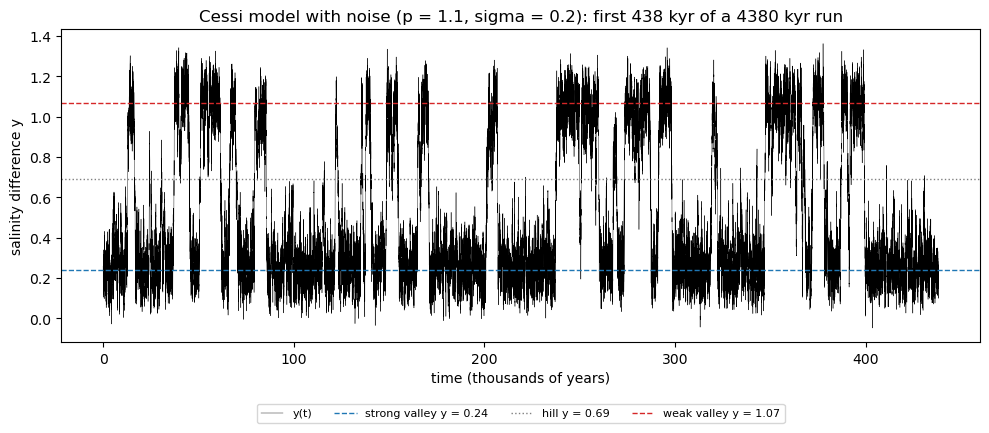

In [12]:
# ---- 5. Figure 1: time series ----
n_plot = int(round(T_PLOT / DT))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_main_kyr[:n_plot + 1], y_main[:n_plot + 1], color="k", lw=0.3, label="y(t)")
ax.axhline(y_strong, color="tab:blue", ls="--", lw=1, label=f"strong valley y = {y_strong:.2f}")
ax.axhline(y_hill, color="gray", ls=":", lw=1, label=f"hill y = {y_hill:.2f}")
ax.axhline(y_weak, color="tab:red", ls="--", lw=1, label=f"weak valley y = {y_weak:.2f}")
ax.set_xlabel("time (thousands of years)")
ax.set_ylabel("salinity difference y")
ax.set_title(f"Cessi model with noise (p = {P}, sigma = {SIGMA_MAIN}): "
             f"first {T_PLOT * DIFFUSION_TIME_YR / 1000:.0f} kyr of a "
             f"{T_MAIN * DIFFUSION_TIME_YR / 1000:.0f} kyr run")
# Legend below the axes: the noisy line fills the whole plot area
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_cessi_noise_timeseries.png"), dpi=150)
plt.show()

This figure shows the histogram of y with the theoretical distribution on top. Nothing is fitted.

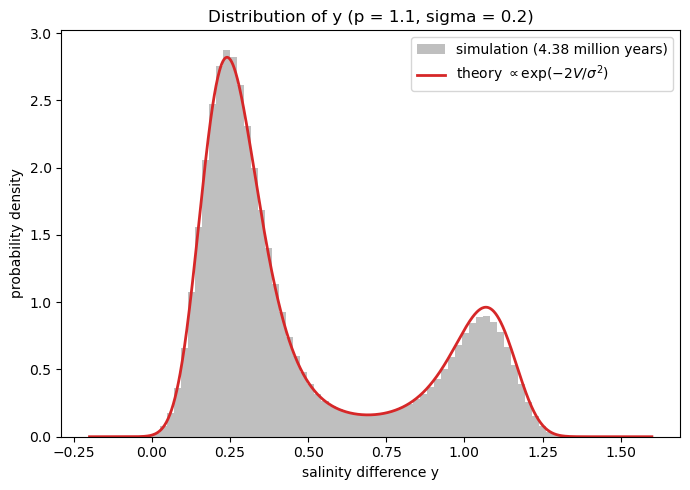

In [13]:
# ---- 6. Figure 2: histogram vs theory ----
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(y_main, bins=N_BINS, range=(-0.2, 1.6), density=True, color="0.75",
        label=f"simulation ({T_MAIN * DIFFUSION_TIME_YR / 1e6:.2f} million years)")
ax.plot(y_grid, p_theory, color="tab:red", lw=2,
        label=r"theory $\propto \exp(-2V/\sigma^2)$")
ax.set_xlabel("salinity difference y")
ax.set_ylabel("probability density")
ax.set_title(f"Distribution of y (p = {P}, sigma = {SIGMA_MAIN})")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_cessi_noise_histogram.png"), dpi=150)
plt.show()

This is the Kramers plot: the simulated waiting times, the straight-line fit and Kramers' full formula.

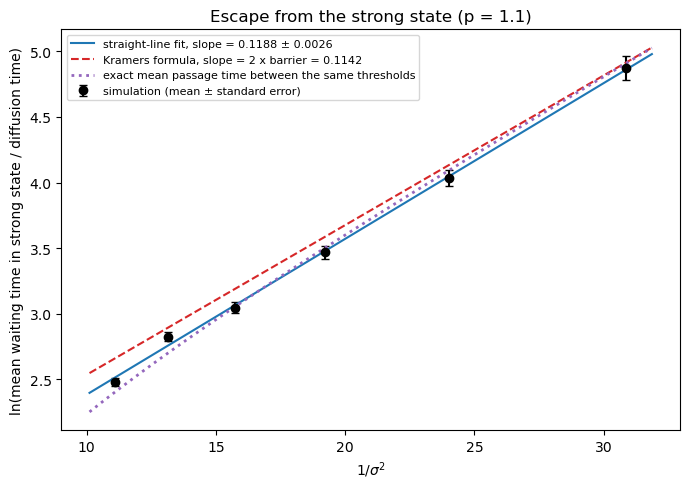

In [14]:
# ---- 7. Figure 3: Kramers plot ----
x_line = np.linspace(inv_sigma2.min() - 1, inv_sigma2.max() + 1, 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(inv_sigma2, log_wait, yerr=stderr_wait / mean_wait, fmt="o", color="k",
            capsize=3, label="simulation (mean ± standard error)")
ax.plot(x_line, intercept + slope * x_line, color="tab:blue",
        label=f"straight-line fit, slope = {slope:.4f} ± {slope_se:.4f}")
ax.plot(x_line, np.log(kramers_prefactor) + 2 * barrier_strong * x_line, color="tab:red", ls="--",
        label=f"Kramers formula, slope = 2 x barrier = {2 * barrier_strong:.4f}")
exact_line = [exact_mean_passage_time(low_threshold, high_threshold, P, 1.0 / np.sqrt(x)) for x in x_line]
ax.plot(x_line, np.log(exact_line), color="tab:purple", ls=":", lw=2,
        label="exact mean passage time between the same thresholds")
ax.set_xlabel(r"$1/\sigma^2$")
ax.set_ylabel("ln(mean waiting time in strong state / diffusion time)")
ax.set_title(f"Escape from the strong state (p = {P})")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_cessi_kramers.png"), dpi=150)
plt.show()

Finally I print the landscape numbers, the example run statistics, the Kramers table and fit, and the time step check.

In [15]:
# ---- 8. Print the key numbers ----
print(f"Landscape at p = {P}: strong valley {y_strong:.4f}, hill {y_hill:.4f}, weak valley {y_weak:.4f}")
print(f"Flip thresholds: low = {low_threshold:.4f}, high = {high_threshold:.4f}")
print(f"Barrier from strong valley = {barrier_strong:.5f}, so 2 x barrier = {2 * barrier_strong:.5f}")
print()
print(f"Example run, sigma = {SIGMA_MAIN}, {T_MAIN:.0f} diffusion times "
      f"({T_MAIN * DIFFUSION_TIME_YR / 1e6:.2f} million years):")
print(f"  flips: {flips_main}")
print(f"  mean time in strong state: {np.mean(s_waits_main):.1f} diffusion times "
      f"({np.mean(s_waits_main) * DIFFUSION_TIME_YR / 1000:.1f} kyr)")
print(f"  mean time in weak state:   {np.mean(w_waits_main):.1f} diffusion times "
      f"({np.mean(w_waits_main) * DIFFUSION_TIME_YR / 1000:.1f} kyr)")
print(f"  fraction of time with y below the hill: {fraction_strong:.3f} ± {fraction_strong_se:.3f}  "
      f"(theory {fraction_strong_theory:.3f})")
print()
print("Kramers test (times in diffusion times; 'exact' = exact mean passage time):")
print(f"{'sigma':>7} {'1/sigma^2':>10} {'flips':>6} {'mean wait':>10} {'std err':>8} "
      f"{'exact, from':>12} {'exact, from':>12} {'Kramers':>8}")
print(f"{'':>7} {'':>10} {'':>6} {'':>10} {'':>8} {'threshold':>12} {'valley':>12} {'formula':>8}")
for k in range(len(SIGMAS)):
    tau_kramers = kramers_prefactor * np.exp(2 * barrier_strong / SIGMAS[k] ** 2)
    print(f"{SIGMAS[k]:7.3f} {inv_sigma2[k]:10.2f} {flips_per_level[k]:6d} {mean_wait[k]:10.2f} "
          f"{stderr_wait[k]:8.2f} {exact_from_threshold[k]:12.2f} {exact_from_valley[k]:12.2f} {tau_kramers:8.2f}")
    if flips_per_level[k] < MIN_FLIPS:
        print(f"   WARNING: fewer than {MIN_FLIPS} flips at sigma = {SIGMAS[k]:.3f}")
print(f"Fitted slope of ln(wait) vs 1/sigma^2: {slope:.4f} ± {slope_se:.4f} (standard error), "
      f"95% interval {slope - slope_ci95:.4f} to {slope + slope_ci95:.4f}")
print(f"2 x barrier height from step 3:        {2 * barrier_strong:.4f}")
print()
print(f"Time step check at sigma = {SIGMA_DT_CHECK} ({N_WALKERS} walkers from the low to the high threshold):")
print(f"  dt = {DT}:    mean passage time {check_mean_1:.3f} ± {check_se_1:.3f}")
print(f"  dt = {DT_FINE}:  mean passage time {check_mean_2:.3f} ± {check_se_2:.3f}")
print(f"  exact:          {check_exact:.3f}")


Landscape at p = 1.1: strong valley 0.2402, hill 0.6911, weak valley 1.0687
Flip thresholds: low = 0.4656, high = 0.8799
Barrier from strong valley = 0.05710, so 2 x barrier = 0.11420

Example run, sigma = 0.2, 20000 diffusion times (4.38 million years):
  flips: 411
  mean time in strong state: 71.5 diffusion times (15.7 kyr)
  mean time in weak state:   25.4 diffusion times (5.6 kyr)
  fraction of time with y below the hill: 0.739 ± 0.024  (theory 0.724)

Kramers test (times in diffusion times; 'exact' = exact mean passage time):
  sigma  1/sigma^2  flips  mean wait  std err  exact, from  exact, from  Kramers
                                                 threshold       valley  formula
  0.180      30.86    234     130.74    11.69       135.51       142.72   136.41
  0.204      24.03    492      56.50     3.37        60.00        64.69    62.50
  0.228      19.24    827      32.04     1.55        33.23        36.61    36.15
  0.252      15.75   1212      21.00     0.86        21.1